# Chapter 6 — Discrete vs Continuous Thinking

> **Prerequisites:** ch001–ch005
>
> **You will learn:**
> - The fundamental divide between discrete and continuous mathematics and why it matters
> - How computers force everything continuous into discrete approximations
> - When discrete models are exact and when continuous models are better
> - The bridge between the two: limits, sampling, and discretization
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

All of mathematics divides into two universes:

**Discrete mathematics** deals with objects that come in separate, countable pieces: integers, graphs, sequences, sets, logic. There are no values between 3 and 4. A function is either defined at a point or it isn't.

**Continuous mathematics** deals with objects that vary smoothly: real numbers, functions, curves, differential equations. Between any two values there are infinitely many others.

This is not just a philosophical distinction. It determines which tools apply. Differential calculus only makes sense for continuous functions. Combinatorics only makes sense for discrete objects. Using the wrong tool on the wrong object produces nonsense.

**The programmer's predicament:** computers are discrete machines. They store finite approximations of continuous values (floats) and execute discrete step sequences. Every time you use a float, you are approximating a continuous quantity with a discrete one. Understanding this boundary prevents entire classes of bugs.

**Common misconception:** Continuous is more "precise" than discrete.

The opposite is often true. Discrete quantities can be represented exactly. The integer 7 is exactly 7. The float `0.1` is not exactly 0.1 — it is a 64-bit discrete approximation to the continuous real number one-tenth.

## 2. Intuition & Mental Models

**Physical analogy:** Pixels vs. a photograph. A digital image is discrete: a grid of pixels, each an integer triple (R,G,B). A real scene is continuous: light intensity varies smoothly at every point. The pixel grid is a discrete approximation. Resolution is the parameter controlling how fine the discrete grid is — and therefore how closely it approximates the continuous original.

**Computational analogy:** Integer arithmetic vs. floating-point arithmetic. `3 + 4 = 7` is exact; no approximation. `0.1 + 0.2 = 0.30000000000000004` is an approximation error from forcing a continuous value into a finite binary representation. Knowing when you are working in the exact discrete world vs the approximate continuous world prevents subtle bugs.

Recall from ch001 *(Why Programmers Learn Mathematics)*: the formula `n*(n+1)//2` used integer arithmetic — exact. The exponential growth models in ch003 used floats — approximate. The distinction was implicit there; here it is explicit.

## 3. Visualization

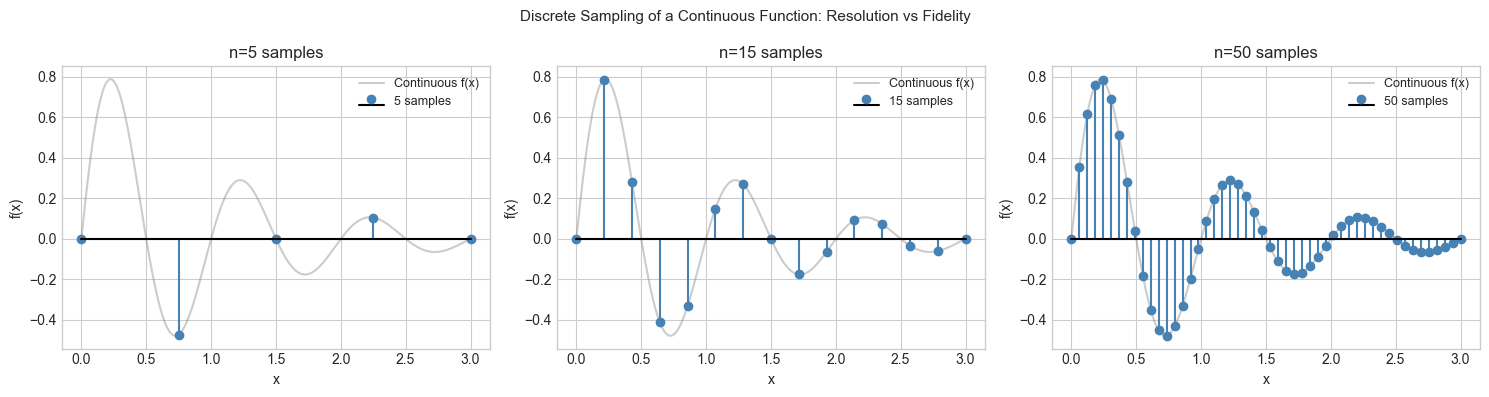

Exact integer arithmetic:
  3 + 4 = 7  (exact)
  10 // 3 = 3  (exact integer division)

Approximate float arithmetic:
  0.1 + 0.2 = 0.30000000000000004  (not 0.3!)
  1.0 - 0.9 - 0.1 = -2.7755575615628914e-17  (not 0.0!)
  sum(0.1 for _ in range(10)) = 1.0  (not 1.0!)


In [1]:
# --- Visualization: Discrete approximation of a continuous function ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

f = lambda x: np.sin(2 * np.pi * x) * np.exp(-x)

x_cont = np.linspace(0, 3, 1000)
y_cont = f(x_cont)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Three levels of discretization
for ax, n_points in zip(axes, [5, 15, 50]):
    x_disc = np.linspace(0, 3, n_points)
    y_disc = f(x_disc)
    ax.plot(x_cont, y_cont, 'gray', alpha=0.4, linewidth=1.5, label='Continuous f(x)')
    ax.stem(x_disc, y_disc, linefmt='steelblue', markerfmt='o',
             basefmt='k-', label=f'{n_points} samples')
    ax.set_title(f'n={n_points} samples')
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.legend(fontsize=9)

plt.suptitle('Discrete Sampling of a Continuous Function: Resolution vs Fidelity', fontsize=11)
plt.tight_layout()
plt.show()

# Show exact vs approximate arithmetic
print("Exact integer arithmetic:")
print(f"  3 + 4 = {3 + 4}  (exact)")
print(f"  10 // 3 = {10 // 3}  (exact integer division)")
print()
print("Approximate float arithmetic:")
print(f"  0.1 + 0.2 = {0.1 + 0.2}  (not 0.3!)")
print(f"  1.0 - 0.9 - 0.1 = {1.0 - 0.9 - 0.1}  (not 0.0!)")
print(f"  sum(0.1 for _ in range(10)) = {sum(0.1 for _ in range(10))}  (not 1.0!)")

## 4. Mathematical Formulation

The bridge between discrete and continuous is the **limit**.

**Discretization:** Given a continuous function $f: \mathbb{R} \to \mathbb{R}$, a discretization with step size $h$ produces the sequence $\{f(nh) : n \in \mathbb{Z}\}$.

**Reconstruction error** (sampling theorem): If $f$ has maximum frequency $B$ (in Hertz), then sampling at rate $\geq 2B$ allows exact reconstruction. This is Shannon's sampling theorem — the discrete sequence contains all information about the continuous function, provided the sampling rate is sufficient.

**The limit as bridge:** The derivative is defined as:
$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

The right-hand side is a discrete finite difference (computable). The limit takes it to the continuous derivative (the object of calculus). This bridge is why numerical methods work: we compute discrete approximations and the limit guarantees they converge to the continuous answer.

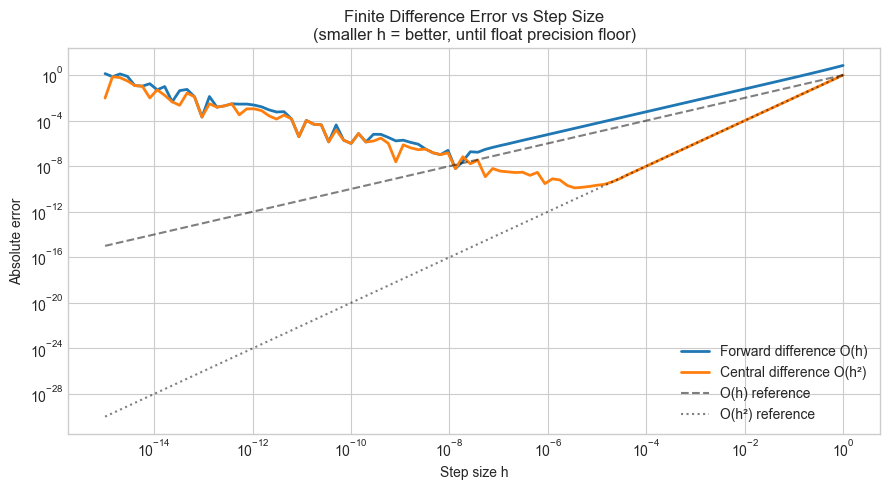

Key observation: error decreases as h → 0, then INCREASES.
The increase is from floating-point cancellation (discrete arithmetic).
The optimal h balances truncation error (continuous) and roundoff (discrete).


In [2]:
# --- Implementation: Finite difference approximation of derivative ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def finite_difference(f, x, h):
    """
    Approximate f'(x) using forward finite difference.
    Discrete bridge to the continuous derivative.
    
    Formula: f'(x) ≈ (f(x+h) - f(x)) / h
    Error: O(h) — goes to zero as h → 0
    """
    return (f(x + h) - f(x)) / h

def central_difference(f, x, h):
    """
    Approximate f'(x) using central finite difference.
    Formula: f'(x) ≈ (f(x+h) - f(x-h)) / (2h)
    Error: O(h²) — more accurate than forward difference
    """
    return (f(x + h) - f(x - h)) / (2 * h)

# Test on f(x) = x³, true f'(x) = 3x²
f = lambda x: x**3
f_prime_true = lambda x: 3 * x**2

X = 2.0
TRUE_DERIV = f_prime_true(X)

h_vals = np.logspace(-15, 0, 100)
fwd_errors = [abs(finite_difference(f, X, h) - TRUE_DERIV) for h in h_vals]
cen_errors = [abs(central_difference(f, X, h) - TRUE_DERIV) for h in h_vals]

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(h_vals, fwd_errors, label='Forward difference O(h)', linewidth=2)
ax.loglog(h_vals, cen_errors, label='Central difference O(h²)', linewidth=2)
ax.loglog(h_vals, h_vals, 'k--', alpha=0.5, label='O(h) reference')
ax.loglog(h_vals, h_vals**2, 'k:', alpha=0.5, label='O(h²) reference')
ax.set_xlabel('Step size h')
ax.set_ylabel('Absolute error')
ax.set_title('Finite Difference Error vs Step Size\n(smaller h = better, until float precision floor)')
ax.legend()
plt.tight_layout()
plt.show()

print("Key observation: error decreases as h → 0, then INCREASES.")
print("The increase is from floating-point cancellation (discrete arithmetic).")
print("The optimal h balances truncation error (continuous) and roundoff (discrete).")

## 5. Python Implementation

*(Finite difference implementations above.)*

## 6. Experiments

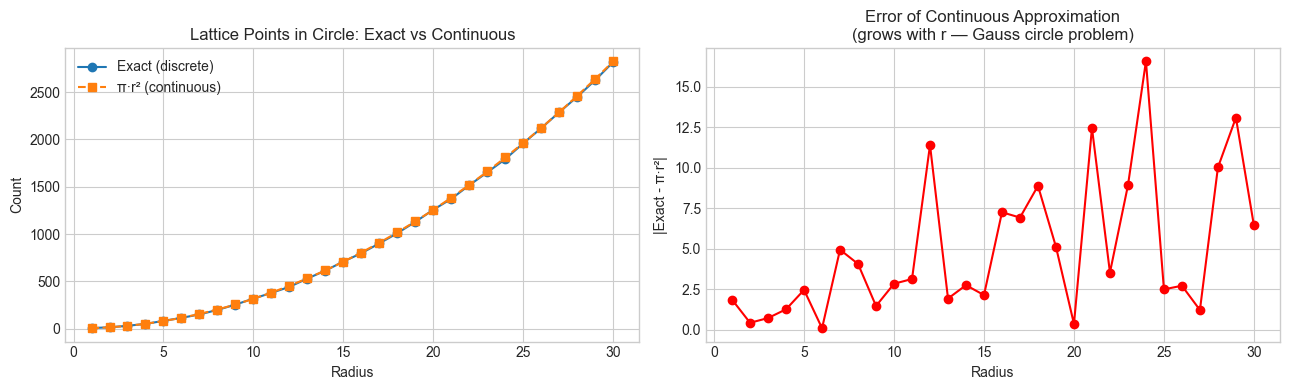

The continuous approximation (π·r²) gets better relatively, but worse absolutely.
This is the Gauss circle problem — bounding the error is an open research area.


In [3]:
# --- Experiment: When discrete models are exact ---
# Hypothesis: For problems defined over integers, discrete models give
# exact answers while continuous approximations introduce error.
# Try changing: N

import numpy as np

N = 1000  # <-- try: 100, 10000

# Problem: count lattice points (integer coordinates) inside a circle of radius r
def count_lattice_points_discrete(r):
    """Exact count: check every integer point."""
    r_int = int(r)
    count = 0
    for x in range(-r_int, r_int + 1):
        for y in range(-r_int, r_int + 1):
            if x*x + y*y <= r*r:
                count += 1
    return count

def count_lattice_points_continuous(r):
    """Continuous approximation: area of circle = pi*r^2."""
    return np.pi * r * r

radii = np.arange(1, 31)
exact   = [count_lattice_points_discrete(r) for r in radii]
approx  = [count_lattice_points_continuous(r) for r in radii]
errors  = [abs(e - a) for e, a in zip(exact, approx)]

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(radii, exact, 'o-', label='Exact (discrete)')
axes[0].plot(radii, approx, 's--', label='π·r² (continuous)')
axes[0].set_xlabel('Radius'); axes[0].set_ylabel('Count')
axes[0].set_title('Lattice Points in Circle: Exact vs Continuous')
axes[0].legend()

axes[1].plot(radii, errors, 'ro-')
axes[1].set_xlabel('Radius'); axes[1].set_ylabel('|Exact - π·r²|')
axes[1].set_title('Error of Continuous Approximation\n(grows with r — Gauss circle problem)')

plt.tight_layout(); plt.show()

print("The continuous approximation (π·r²) gets better relatively, but worse absolutely.")
print("This is the Gauss circle problem — bounding the error is an open research area.")

## 7. Exercises

**Easy 1.** Python's `float` type uses 64-bit IEEE 754. Use `import struct` and bit manipulation to inspect the binary representation of `0.1`. How many bits are used for the mantissa? What is the exact value stored? *(Expected: printed binary components)*

**Easy 2.** The central difference formula has error O(h²). Verify this empirically: plot the error for `f(x) = sin(x)` at x=1.0 as a function of h, and confirm the slope on a log-log plot is approximately 2. *(Expected: slope ≈ 2 for intermediate h values)*

**Medium 1.** The forward Euler method solves an ODE discretely: given $dy/dx = f(x,y)$, approximate $y(x+h) \approx y(x) + h \cdot f(x, y(x))$. Implement Euler's method and solve $dy/dx = y$ (true solution: $y = e^x$) from x=0 to x=2. Plot the error vs step size h. At what h does floating-point error begin to dominate truncation error?

**Medium 2.** The harmonic series $\sum_{k=1}^n 1/k$ diverges (grows without bound). But a computer summing in order from k=1 will eventually stop showing growth due to floating-point precision. At what n does `total += 1/n` have no effect because `1/n` is below the float precision floor? Find this experimentally.

**Hard.** Shannon's sampling theorem says a signal with maximum frequency B can be exactly reconstructed from samples at rate ≥ 2B. Demonstrate this computationally: create a sum of sinusoids with max frequency 10Hz, sample it at 25Hz (above Nyquist) and at 15Hz (below Nyquist). Reconstruct using sinc interpolation and compare the two reconstructions. Show the aliasing artifact in the undersampled case.

## 8. Mini Project

**Discretization Error Atlas**: For five standard continuous functions (sin, exp, log, sqrt, 1/x), measure how discretization quality (step size) trades off against approximation error for both derivative and integral estimation.

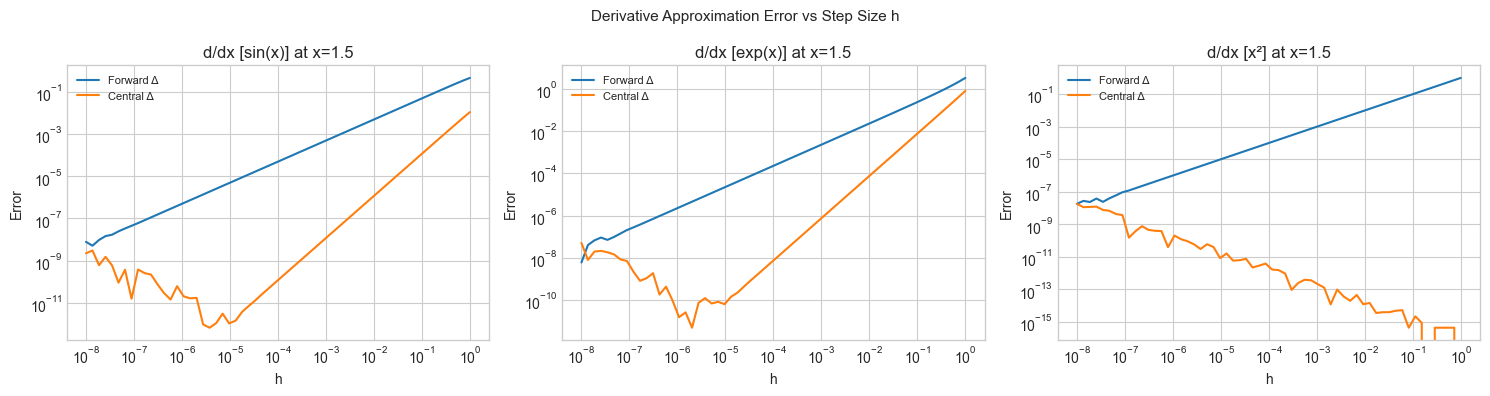

In [4]:
# --- Mini Project: Discretization Error Atlas ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

functions = {
    'sin(x)':  (np.sin,    np.cos,      1.0, 0.0, 1.0),   # f, f', x0, true_int_from0
    'exp(x)':  (np.exp,    np.exp,      1.0, np.e - 1, np.e),
    'x²':      (lambda x: x**2, lambda x: 2*x, 2.0, 1/3, 4.0),
}

H_VALS = np.logspace(-8, 0, 60)
X0 = 1.5

fig, axes = plt.subplots(1, len(functions), figsize=(15, 4))

for ax, (name, (f, f_prime, x0, _, true_deriv)) in zip(axes, functions.items()):
    true_d = f_prime(X0)
    fwd_err = [abs((f(X0+h) - f(X0))/h - true_d) for h in H_VALS]
    cen_err = [abs((f(X0+h) - f(X0-h))/(2*h) - true_d) for h in H_VALS]
    
    ax.loglog(H_VALS, fwd_err, label='Forward Δ')
    ax.loglog(H_VALS, cen_err, label='Central Δ')
    ax.set_xlabel('h'); ax.set_ylabel('Error')
    ax.set_title(f'd/dx [{name}] at x={X0}')
    ax.legend(fontsize=8)

plt.suptitle('Derivative Approximation Error vs Step Size h', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Chapter Summary & Connections

- Discrete mathematics deals with countable, exact objects; continuous mathematics deals with smooth, infinitely divisible ones
- Computers are discrete machines — every continuous quantity in a program is an approximation with bounded precision
- Finite differences are the discrete bridge to continuous derivatives; the limit is the mathematical bridge between both worlds
- Discretization introduces two error types: truncation error (from using finite h) and roundoff error (from float precision) — these trade off, producing an optimal h

**Forward:** The finite difference approximation of derivatives (introduced here) is formalized in ch207 — Numerical Derivatives, where the optimal step size is derived analytically. The discretization tradeoff reappears in ch223 — Numerical Integration. Floating-point precision connects directly to ch038 — Precision and Floating Point Errors.

**Backward:** ch003 *(Abstraction and Modeling)* showed that models are always approximations. This chapter identifies the specific approximation made when forcing continuous mathematics into a discrete computer.